Two-layer neural network w/ three class classification

- Input: $x^{(i)} \in \mathbb{R}^2$
- Hidden layers: 2 layers, each with 3 hidden units
- Activation: ReLU
- Output: 3 logits → softmax probabilities
- Loss: categorical cross-entropy


In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
from autograd import grad
import autograd.numpy as anp  # autograd-compatible numpy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [11]:
## Generate data
X, y = make_classification(
    n_samples=3000, n_features=2, n_classes=3, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=0
)

In [12]:
## Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

def one_hot(y, K):
    oh = np.zeros((y.shape[0], K))
    oh[np.arange(y.shape[0]), y] = 1
    return oh

Y_train = one_hot(y_train, 3)
Y_test = one_hot(y_test, 3)

In [13]:
## Helper functions
# ReLU activation
# softmax function for multiclass probs
# two hidden layers

def relu(x):
    return anp.maximum(0, x)

def softmax(z):
    expz = anp.exp(z - anp.max(z, axis=1, keepdims=True))
    return expz / anp.sum(expz, axis=1, keepdims=True)

def forward(params, X):
    h1 = relu(anp.dot(X, params["W1"]) + params["b1"])
    h2 = relu(anp.dot(h1, params["W2"]) + params["b2"])
    out = anp.dot(h2, params["W3"]) + params["b3"]
    return softmax(out)

def loss_fn(params, X, Y):
    yhat = forward(params, X)    # gets the matrix of probs 
    return -anp.mean(anp.sum(Y * anp.log(yhat + 1e-8), axis=1))  

def accuracy_fn(params, X, y_true):
    yhat = forward(params, X)   # get probs again
    y_pred = np.argmax(np.array(yhat), axis=1)     # pick highest prob class
    return np.mean(y_pred == y_true)               # boolean array for accuracy as decimal

In [14]:
# initialize
grad_loss = grad(loss_fn)
lr = 0.1
epochs = 300
input_size = 2
hidden1_size = 3
hidden2_size = 3
output_size = 3  # 3 classes

params = {
    "W1": 0.01 * np.random.randn(input_size, hidden1_size),
    "b1": np.zeros((1, hidden1_size)),
    "W2": 0.01 * np.random.randn(hidden1_size, hidden2_size),
    "b2": np.zeros((1, hidden2_size)),
    "W3": 0.01 * np.random.randn(hidden2_size, output_size),
    "b3": np.zeros((1, output_size))
}

losses_train = []
losses_test = []
acc_train = []
acc_test = []



In [15]:
from autograd import grad
grad_loss = grad(loss_fn)

## Train model

for epoch in range(epochs):
    ypred_train = forward(params, X_train)        # again, forward calculates model prediction for input
    current_loss_train = loss_fn(params, X_train, Y_train)

    grads = grad_loss(params, X_train, Y_train)   # calculates gradients for each parameter
    for key in params.keys():                     # grads is dict of gradient values
        params[key] -= lr * grads[key]            # subtracts here

    current_acc_train = accuracy_fn(params, X_train, y_train)

    current_loss_test = loss_fn(params, X_test, Y_test)
    current_acc_test = accuracy_fn(params, X_test, y_test)

    losses_train.append(current_loss_train)
    losses_test.append(current_loss_test)
    acc_train.append(current_acc_train)
    acc_test.append(current_acc_test)

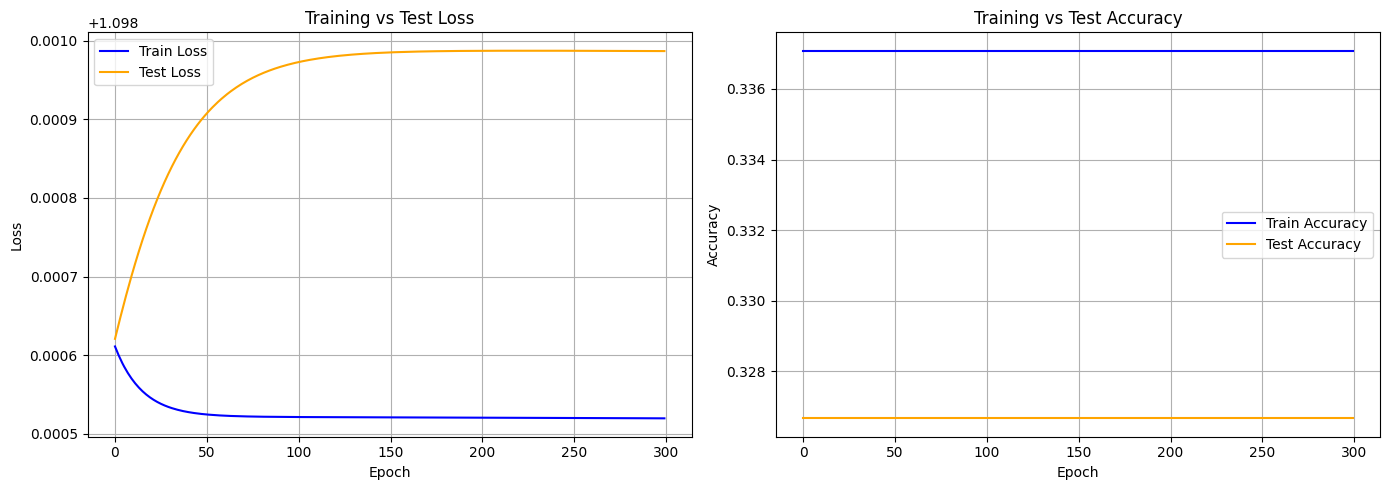

In [16]:
## Plot loss curves
# demonstrates overfitting

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(losses_train, label='Train Loss', color='blue')
axes[0].plot(losses_test, label='Test Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Test Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(acc_train, label='Train Accuracy', color='blue')
axes[1].plot(acc_test, label='Test Accuracy', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Test Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


Optimizer comparison for training

In [17]:
np.random.seed(0)
torch.manual_seed(0)

N = 1500
D = 2
K = 3

X = torch.zeros((N, D), dtype=torch.float32)
y = torch.zeros(N, dtype=torch.long)

points_per_class = N // K

for j in range(K):
    ix = range(j * points_per_class, (j + 1) * points_per_class)
    r = torch.linspace(0.0, 1, points_per_class)
    t = torch.linspace(j * 4, (j + 1) * 4, points_per_class) + torch.randn(points_per_class) * 0.2
    X[ix] = torch.stack([r * torch.sin(t), r * torch.cos(t)], dim=1)
    y[ix] = j
    


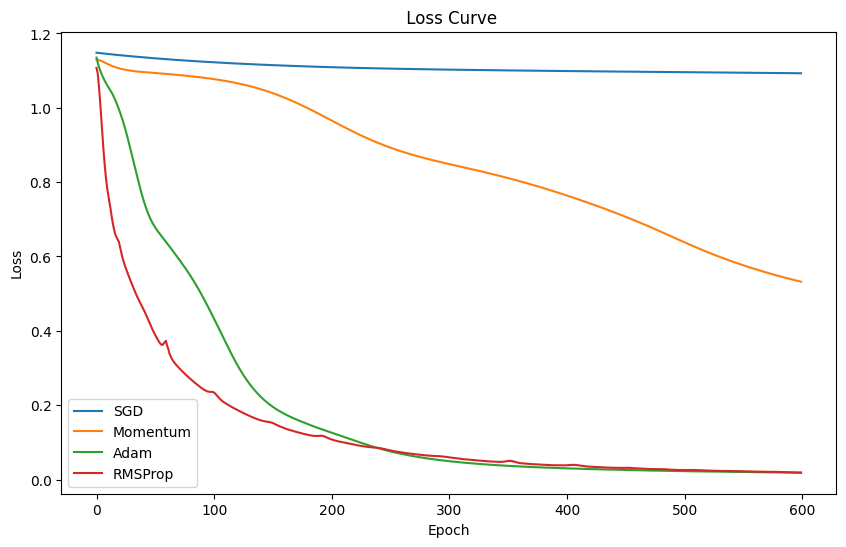

In [18]:
## Create neural network class for optimizers

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 10)
        self.fc2 = nn.Linear(10, 10)
        self.fc3 = nn.Linear(10, 3)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


## Train with SGD, Adam, Momentum, RMSProp
def train_model(optimizer_name, lr=0.01, epochs=600):
    model = SimpleNN()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "Momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "RMSProp":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError("Unknown optimizer")

    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

optimizers = ["SGD", "Momentum", "Adam", "RMSProp"]

# store losses in dict
losses3 = {}

for optimizer in optimizers:
  model_loss = train_model(optimizer)
  losses3[optimizer] = model_loss
    
# plot loss curves 

plt.figure(figsize=(10, 6))
for optimizer in optimizers:
    plt.plot(losses3[optimizer], label=optimizer)

plt.title(" Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()